## Setup

### Manage Packages

In [83]:
# Import all required packages
import pandas as pd                   # For data manipulation and analysis
import io
import gymnasium as gym
import numpy as np
import os
import pickle
import copy
import random
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.ticker as ticker
import warnings
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
import torch
import networkx as nx
from tqdm import tqdm
from scipy.stats import ttest_ind
import seaborn as sns

# Import custom zero counting function
def count_zeros(arr):
    return np.count_nonzero(arr < 0.00001)

# Import custom environment .py file
import env_TA as ce #modified for curriculum learning

### Input Parameters

In [110]:
#User Determined Settings
graphName = "G4x5"  # Graph nodes and edges to use
env_deterministic = False
env_fixed_costs = False
env_initial_budget = None
env_multiple_interdiction = False
env_attacker_strategy = 'zero_sum'  # canalize   isolate   divert  zero_sum

model_name = "G4x5_S_MaskablePPO_zero_sum_V2_GPU"        # G4x5_S_MaskablePPO_EX003I   G4x5_S_MaskablePPO_EX003Z   G4x5_S_PPO_EX001C  G4x5_S_MaskablePPO_zero_sum_V1
model_timesteps = 4284000            # Set a number, 1512000, or  None

### Create Environment and Load Optimal Solutions

In [111]:
## Create Environment
# Create nodes and edges
node_filename = f"{graphName}_Nodes.csv"  # Dynamically include graphName
edge_filename = f"{graphName}_Edges.csv"  # Dynamically include graphName

nodes, edges = ce.create_nodes_edges(node_filename, edge_filename)

# Load Environment
env = ce.CustomEnv(nodes, edges, deterministic_agent=env_deterministic,
                   multiple_interdiction_attempts=env_multiple_interdiction,
                   attacker_strategy = env_attacker_strategy,
                   initial_budget=env_initial_budget)

### Create Agent

In [112]:
# Get the current working directory
current_dir = os.getcwd()
models_dir = os.path.join(current_dir, '..', 'Trained_RL_Models')

# LOAD Previous saved model
if model_timesteps == None:
    model_path = f"{models_dir}/{model_name}/best_model"
else:
    model_path = f"{models_dir}/{model_name}/{model_name}_{model_timesteps}_steps"
data = np.load(f"{models_dir}/{model_name}/evaluations.npz")

# Load the model
if "MaskablePPO" in model_name:
    from sb3_contrib import MaskablePPO
    agent=MaskablePPO.load(model_path,)
elif "PPO" in model_name:
    from stable_baselines3 import PPO
    agent=PPO.load(model_path, env=env)
elif "DQN" in model_name:
    from stable_baselines3 import DQN
    agent=DQN.load(model_path, env=env)
elif "A2C" in model_name:
    from stable_baselines3 import A2C
    agent=A2C.load(model_path, env=env)

### Load Optimal Solutions

In [113]:
## Load Optimal Solutions
#load and Read Pickle File of Backward Induction Solutions
# Use the same path and filename as in your saving code
save_filename = f"{graphName}_{env_attacker_strategy}_solution.pkl"
save_path = os.path.join(current_dir, '..', 'Solutions', save_filename)

# Open the pickle file in binary read mode and load the data
with open(save_path, "rb") as f:
    results = pickle.load(f)

# Now you can access the saved data
print("Episodes completed:", results["last_episode"] + 1)
print("Mean Objective values:", np.mean(results["optimal_obj_vals"]))
#print("Interdiction sets:", results["all_optimal_interdiction_edges"])
print("Mean Solution times:", np.mean(results["optimal_solution_times"]))

optimal_obj_vals = results["optimal_obj_vals"]
all_optimal_interdiction_edges = results["all_optimal_interdiction_edges"]
optimal_solution_times = results["optimal_solution_times"]

Episodes completed: 10000
Mean Objective values: 99.06288501467908
Mean Solution times: 656.9177385002927


## Analysis

### Training Progress

#### Code

In [57]:
def plot_training_curve(data, model_name, figsize=(6, 3.4), xlim=(0, 5000000), ylim=(0, 5), 
                       xlabel='Training Step', ylabel='Mean Episode Reward', 
                       title=None, x_tick_interval=1000000, show_legend=True):
    """
    Plot training curve with consistent formatting for reinforcement learning results
    
    Parameters:
    - data: Dictionary containing 'timesteps' and 'results' keys
    - model_name: String label for the plotted line
    - figsize: Tuple for figure size (width, height)
    - xlim: Tuple for x-axis limits (min, max)
    - ylim: Tuple for y-axis limits (min, max)
    - xlabel: String for x-axis label
    - ylabel: String for y-axis label
    - title: String for plot title (optional)
    - x_tick_interval: Integer for x-axis tick spacing
    - show_legend: Boolean to show/hide legend
    """
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import numpy as np
    import seaborn as sns
    
    plt.figure(figsize=figsize)
    
    # Set consistent formatting
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
    })
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.family'] = 'STIXGeneral'
    
    # Extract data and compute mean rewards
    timesteps = data['timesteps']
    results = data['results']
    mean_rewards = np.mean(results, axis=1)
    
    # Plot the training curve
    plt.plot(timesteps, mean_rewards, label=model_name)
    
    # Set labels and title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title:
        plt.title(title)
    
    # Show legend if requested
    if show_legend:
        plt.legend()
    
    # Set axis limits
    plt.xlim(xlim[0], xlim[1])
    plt.ylim(ylim[0], ylim[1])
    
    # Set x-axis ticks at specified intervals
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(x_tick_interval))
    
    # Format x-axis tick labels with commas
    def format_func(value, tick_number):
        return f"{value:,.0f}"
    
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    
    # Apply clean styling
    sns.despine()
    plt.show()

#### Plot

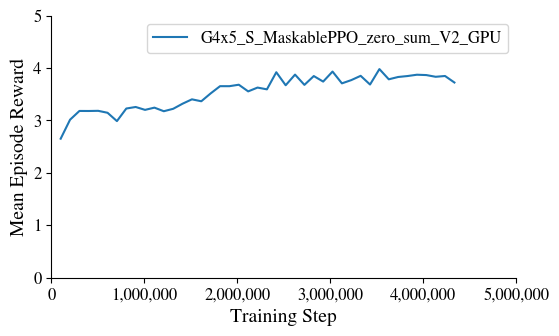

In [114]:
plot_training_curve(data, model_name)

### Generate Optimal Interdicted Edge Histogram

#### Code

In [8]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def plot_edge_histogram_from_lists(edge_lists, title="Interdicted Edge Frequency Histogram", figsize=(12, 6), 
                                 combine_all=True, show_individual=False):
    """
    Create a histogram from a list of lists of edges showing frequency of occurrence.
    
    Parameters:
    edge_lists: List of lists, where each inner list contains edge tuples
                e.g., [[(1,2), (2,3)], [(1,2), (3,4)], [(2,3), (1,2)]]
    title: Title for the plot
    figsize: Figure size (width, height)
    combine_all: If True, combines all edges from all lists into one histogram
    show_individual: If True, shows separate histograms for each list
    
    Returns:
    Dictionary with frequency data
    """
    
    if combine_all:
        # Flatten all edge lists into one big list
        all_edges = []
        for edge_list in edge_lists:
            all_edges.extend(edge_list)
        
        # Count occurrences of each edge across all lists
        edge_counts = Counter(all_edges)
        
        # Sort edges for consistent ordering
        sorted_edges = sorted(edge_counts.keys())
        counts = [edge_counts[edge] for edge in sorted_edges]
        edge_labels = [f"({edge[0]},{edge[1]})" for edge in sorted_edges]
        
        # Create the bar plot
        plt.figure(figsize=figsize)
        bars = plt.bar(range(len(edge_labels)), counts, alpha=0.7, color='steelblue')
        
        # Customize the plot
        plt.xlabel('Edges')
        plt.ylabel('Total Frequency Across 1,000 Episodes')
        plt.title(f"{title}")
        plt.xticks(range(len(edge_labels)), edge_labels, rotation=45, ha='right')
        
        # Add value labels on top of bars
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    str(count), ha='center', va='bottom')
        
        plt.tight_layout()
        plt.grid(axis='y', alpha=0.3)
        plt.show()
        
        return {"combined": edge_counts, "total_edges": len(all_edges), "num_lists": len(edge_lists)}

#### Plot

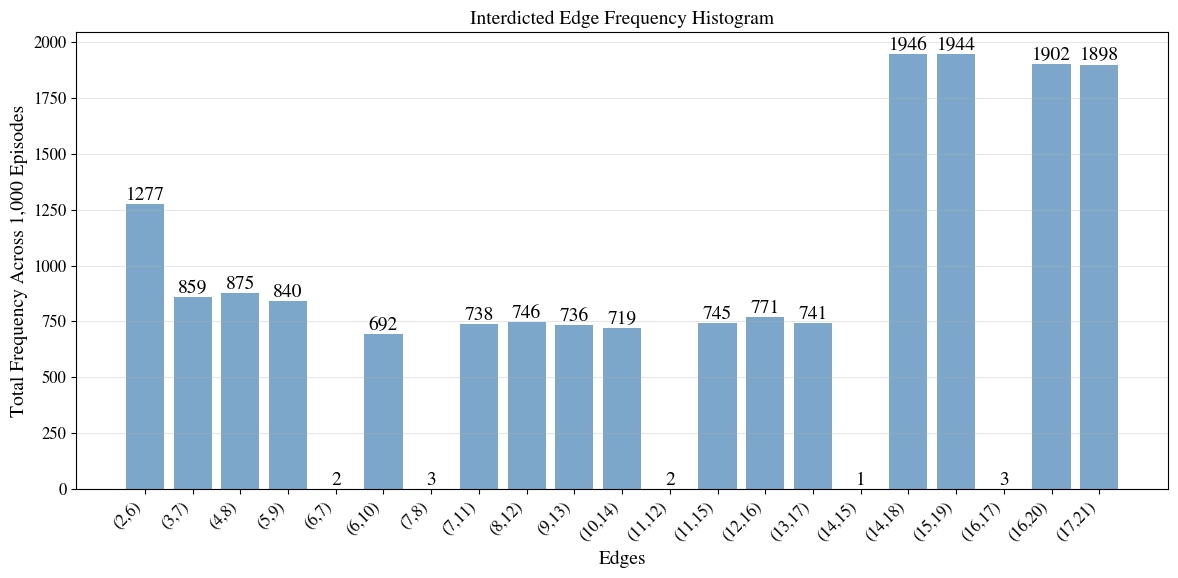

In [89]:
your_edge_lists = all_optimal_interdiction_edges
plots = plot_edge_histogram_from_lists(your_edge_lists)
interdiction_counts=plots['combined']

### Generate Heatmap of Interdicted Edges on Graph

#### Function

In [10]:
def plot_graph_with_node_types(nodes, edges, interdiction_counts, 
                               title="Network Graph with Node Types and Interdiction Counts", 
                               figsize=(12, 6), colormap='Reds'):
    """
    Enhanced plotting function that colors nodes by type and edges by interdiction counts
    
    Parameters:
    - nodes: Dictionary of Node objects
    - edges: Dictionary of Edge objects  
    - interdiction_counts: Dictionary with edge keys and count values
    - title: Graph title
    - figsize: Figure size
    - colormap: Matplotlib colormap for edge coloring ('Reds', 'Blues', 'viridis', etc.)
    """
    import matplotlib.cm as cm
    from matplotlib.colors import Normalize
    
    # Create NetworkX graph
    G = nx.DiGraph()
    
    # Add nodes and edges
    for node_id, node_obj in nodes.items():
        G.add_node(node_id, 
                   pos=(node_obj.xpos, node_obj.ypos),
                   node_type=node_obj.node_type)
    
    for edge_id, edge_obj in edges.items():
        origin, destination = edge_id
        # Get interdiction count for this edge (default to 0 if not found)
        count = interdiction_counts.get(edge_id, 0)
        G.add_edge(origin, destination, 
                   interdictable=edge_obj.interdictable,
                   interdiction_count=count)
    
    plt.figure(figsize=figsize)
    pos = nx.get_node_attributes(G, 'pos')
    
    # Get unique node types and assign colors
    node_types = nx.get_node_attributes(G, 'node_type')
    # Define the order you want in the legend
    desired_order = ['source', 'intermediate', 'sink']
    
    # Filter to only include types that actually exist in your graph
    available_types = set(node_types.values())
    ordered_types = [node_type for node_type in desired_order if node_type in available_types]
    
    # Assign colors to node types in the specified order (swapped source and intermediate)
    colors = plt.cm.Set3(np.linspace(0, 1, len(ordered_types)))
    # Create color mapping with source and intermediate colors swapped
    if len(ordered_types) >= 2:
        # Swap colors for source and intermediate
        color_list = list(colors)
        if 'source' in ordered_types and 'intermediate' in ordered_types:
            source_idx = ordered_types.index('source')
            intermediate_idx = ordered_types.index('intermediate')
            color_list[source_idx], color_list[intermediate_idx] = color_list[intermediate_idx], color_list[source_idx]
        type_color_map = dict(zip(ordered_types, color_list))
    else:
        type_color_map = dict(zip(ordered_types, colors))
    
    # Draw nodes colored by type in the specified order
    for node_type in ordered_types:
        node_list = [node for node, ntype in node_types.items() if ntype == node_type]
        nx.draw_networkx_nodes(G, pos,
                              nodelist=node_list,
                              node_color=[type_color_map[node_type]],
                              node_size=700,
                              alpha=0.9,
                              label=f'{node_type.title()}')  # Capitalize first letter
    
    # Prepare edge coloring based on interdiction counts
    interdictable_edges = [(u, v) for u, v, d in G.edges(data=True) if d['interdictable']]
    non_interdictable_edges = [(u, v) for u, v, d in G.edges(data=True) if not d['interdictable']]
    
    # Get interdiction counts for interdictable edges
    if interdictable_edges:
        edge_counts = [G[u][v]['interdiction_count'] for u, v in interdictable_edges]
        
        # Handle case where all counts are zero
        if max(edge_counts) > 0:
            # Normalize counts for colormap
            norm = Normalize(vmin=0, vmax=max(edge_counts))
            cmap = mpl.colormaps[colormap]  #cm.get_cmap(colormap)  
            edge_colors = [cmap(norm(count)) for count in edge_counts]
            
            # Draw interdictable edges with color based on counts
            nx.draw_networkx_edges(G, pos, 
                                  edgelist=interdictable_edges,
                                  edge_color=edge_colors,
                                  width=5,
                                  alpha=0.8,
                                  arrows=False)
            
            # Add colorbar for edge counts with decreased horizontal spacing
            sm = cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8, pad=0.02)  # Changed pad from 0.1 to 0.02
            cbar.set_label('Interdiction Count', rotation=270, labelpad=15)
            
        else:
            # All counts are zero, draw in default color
            nx.draw_networkx_edges(G, pos, 
                                  edgelist=interdictable_edges,
                                  edge_color='lightcoral',
                                  width=5,
                                  alpha=0.7,
                                  arrows=True)
    
    # Draw non-interdictable edges in gray
    if non_interdictable_edges:
        nx.draw_networkx_edges(G, pos, 
                              edgelist=non_interdictable_edges,
                              edge_color='gray',
                              width=5,
                              alpha=0.5,
                              arrows=False)
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    
    # Create legend with increased line spacing
    legend = plt.legend(scatterpoints=1, loc='upper left', 
                        labelspacing=1.5)    
    legend.set_frame_on(False)  # Enable legend frame
    legend.get_frame().set_facecolor('white')  # Set background color
    legend.get_frame().set_alpha(0.9)  # Set transparency
    
    # Increase spacing between legend entries
    for i, text in enumerate(legend.get_texts()):
        text.set_verticalalignment('center')
    
    # Adjust legend spacing by modifying the legend properties
    plt.setp(legend.get_texts(), fontsize=12)  # Optional: adjust font size   
    plt.tight_layout()
    
    # Print statistics
    total_interdictions = sum(interdiction_counts.values())
    max_count = max(interdiction_counts.values()) if interdiction_counts else 0
    print(f"\nInterdiction Statistics:")
    print(f"- Total interdictions across all edges: {total_interdictions}")
    print(f"- Maximum interdictions on single edge: {max_count}")
    print(f"- Number of edges with interdictions: {sum(1 for count in interdiction_counts.values() if count > 0)}")
    
    plt.show()
    return G

#### Graph


Interdiction Statistics:
- Total interdictions across all edges: 17440
- Maximum interdictions on single edge: 1946
- Number of edges with interdictions: 21


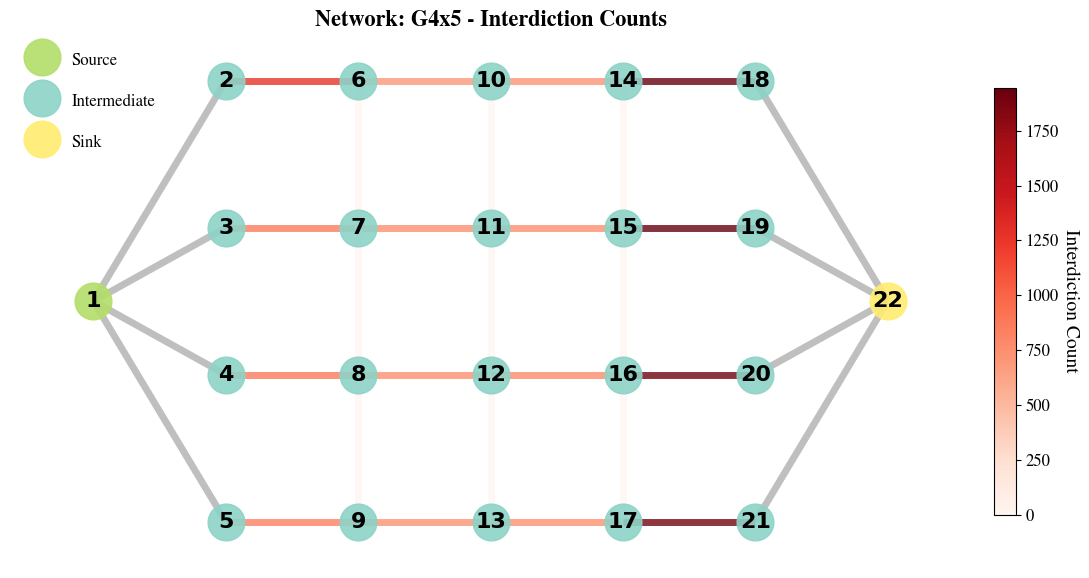

In [115]:
if __name__ == "__main__":
    # Plot with edge colors based on interdiction counts
    G = plot_graph_with_node_types(nodes, edges, interdiction_counts, 
                                   title=f"Network: {graphName} - Interdiction Counts")

### Evaluate Agent Performance Against Optimal Solutions

In [118]:
# Test Agent against a range of scenarios
num_of_scenarios = 10

# Pre-compute constants outside the loop
interdictable_edges_list = list(env.interdictable_edges)

# Initialize arrays to store results
max_flow_vals =  np.zeros(num_of_scenarios)
agent_best_rewards = np.zeros(num_of_scenarios)

# Initialize a dictionary to keep track of actions
action_tally = {i: 0 for i in env.interdictable_edges}

all_agent_actions =[]
agent_solution_times = np.zeros(num_of_scenarios)
#optimal_solution_times=[]

def mask_fn(env):
    """
    Function to generate action mask based on your validation logic
    """
    # Get current state
    remaining_budget = env.state['budget']
    
    # Create action mask - size should match action space
    action_mask = np.ones(env.action_space.n, dtype=np.float32)
    
    # Mask interdictable edges (first 25 actions)
    for action in range(min(env.num_interdictable_edges, env.action_space.n)):
        if not env._validate_action(action, remaining_budget, env.state['edge_interdicted']):
            action_mask[action] = 0.0
    
    # The "do nothing" action (if it exists) is typically always valid
    # It should be at index env.num_interdictable_edges
    # No additional masking needed for "do nothing" action
    return action_mask

agent.policy.eval()
for episode in tqdm(range(num_of_scenarios)):
    obs, _ = env.reset(seed=episode)

    #Determine Original Flow
    max_flow_vals[episode] = env.reference_obj

    action_list = []
    action_list_append = action_list.append  # Cache method reference
    
    start_time = time.perf_counter()
    # Run agent with proper normalization
    with torch.no_grad():
        for _ in range(31):
            action, _ = agent.predict(obs, deterministic=True, action_masks=mask_fn(env))
            # Use wrapper's step method
            obs, reward, done, _, _ = env.step(action)  
            # Tally actions using inner environment
            if action != 500: #env.num_interdictable_edges:
                action_key = interdictable_edges_list[action]
                action_tally[action_key] += 1
                action_list_append(action_key)  # Faster than action_list.append()
            
            if done:
                break
    end_time = time.perf_counter()
    agent_solution_times[episode]=(end_time-start_time)
    all_agent_actions.append(frozenset(action_list))

    if all_agent_actions[episode].issuperset(all_optimal_interdiction_edges[episode]):
        objVal = optimal_obj_vals[episode]
    else:
        # Get final objective value from inner environment
        if env_attacker_strategy == "zero_sum":
            objVal, _ = env._compute_objective_and_flows()
        elif env_attacker_strategy == "isolate":
            objVal, _ = env._calculate_isolate_objective_and_flows()
        elif env_attacker_strategy == "canalize":
            objVal, _ = env._calculate_canalize_objective_and_flows()
        elif env_attacker_strategy == "divert":
            objVal, _ = env._calculate_divert_objective_and_flows()

    agent_best_rewards[episode] = objVal

#Print Results
print("Optimal Time to Solve (Mean): ",np.mean(optimal_solution_times[0:num_of_scenarios-1]))
print("")

relative_errors = abs(agent_best_rewards-optimal_obj_vals[0:num_of_scenarios]) / (max_flow_vals-optimal_obj_vals[0:num_of_scenarios])# Create boolean mask using set operations
    
# Calculate mean relative error
mean_relative_error = np.nanmean(relative_errors)
print(model_name, ": ", count_zeros(relative_errors))
print("Mean Relative Error: ", mean_relative_error)
print("RL Time to Solve (Mean): ", np.mean(agent_solution_times))
print("")

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [01:00<00:00,  6.09s/it]

Optimal Time to Solve (Mean):  640.179231356105

G4x5_S_MaskablePPO_zero_sum_V2_GPU :  4
Mean Relative Error:  0.261123731700977
RL Time to Solve (Mean):  4.406293389998609



In [120]:
print(all_agent_actions)
print(all_agent_actions)

[frozenset({(14, 18), (16, 20)}), frozenset({(15, 19), (17, 21)}), frozenset({(15, 19)}), frozenset({(17, 21)}), frozenset({(16, 20), (15, 19)}), frozenset({(16, 20), (15, 19)}), frozenset({(14, 18), (15, 19)}), frozenset({(16, 20), (15, 19)}), frozenset({(16, 20), (17, 21)}), frozenset({(16, 20), (17, 21)})]
[frozenset({(14, 18), (16, 20)}), frozenset({(15, 19), (17, 21)}), frozenset({(15, 19)}), frozenset({(17, 21)}), frozenset({(16, 20), (15, 19)}), frozenset({(16, 20), (15, 19)}), frozenset({(14, 18), (15, 19)}), frozenset({(16, 20), (15, 19)}), frozenset({(16, 20), (17, 21)}), frozenset({(16, 20), (17, 21)})]


In [117]:
relative_errors2= relative_errors
all_agent_actions2 = all_agent_actions

In [88]:
for e in env.edges_reset.items():
    print(e)

((1, 2), <env_TA.Edge object at 0x0000023FB2D817B0>)
((1, 3), <env_TA.Edge object at 0x0000023FB2D80190>)
((1, 4), <env_TA.Edge object at 0x0000023FB2D80C70>)
((1, 5), <env_TA.Edge object at 0x0000023FB2D800A0>)
((1, 6), <env_TA.Edge object at 0x0000023FB2D82FE0>)
((1, 7), <env_TA.Edge object at 0x0000023FB2D80BB0>)
((1, 8), <env_TA.Edge object at 0x0000023FB2D80430>)
((1, 9), <env_TA.Edge object at 0x0000023FB2D80910>)
((1, 10), <env_TA.Edge object at 0x0000023FB2D80A60>)
((1, 11), <env_TA.Edge object at 0x0000023FB2D80AC0>)
((2, 12), <env_TA.Edge object at 0x0000023FB2D80880>)
((3, 13), <env_TA.Edge object at 0x0000023FB2D80400>)
((4, 14), <env_TA.Edge object at 0x0000023FB2D809D0>)
((5, 15), <env_TA.Edge object at 0x0000023FB2D80E20>)
((6, 16), <env_TA.Edge object at 0x0000023FB2D80700>)
((7, 17), <env_TA.Edge object at 0x0000023FB2D80730>)
((8, 18), <env_TA.Edge object at 0x0000023FB2D805E0>)
((9, 19), <env_TA.Edge object at 0x0000023FB2D80B50>)
((10, 20), <env_TA.Edge object at 0x

In [205]:
# Test Agent against a range of scenarios
num_of_scenarios = 100

# Pre-compute constants outside the loop
interdictable_edges_list = list(env.interdictable_edges)

# Initialize arrays to store results
max_flow_vals = np.zeros(num_of_scenarios)
agent_best_rewards = np.zeros(num_of_scenarios)

# Initialize a dictionary to keep track of actions
action_tally = {i: 0 for i in env.interdictable_edges}

all_agent_actions = []
agent_solution_times = np.zeros(num_of_scenarios)

def mask_fn(env):
    """
    Function to generate action mask based on your validation logic
    """
    # Get current state
    remaining_budget = env.state['budget']
    
    # Create action mask - size should match action space
    action_mask = np.ones(env.action_space.n, dtype=np.float32)
    
    # Mask interdictable edges (first 25 actions)
    for action in range(min(env.num_interdictable_edges, env.action_space.n)):
        if not env._validate_action(action, remaining_budget, env.state['edge_interdicted']):
            action_mask[action] = 0.0
    
    # The "do nothing" action (if it exists) is typically always valid
    # It should be at index env.num_interdictable_edges
    # No additional masking needed for "do nothing" action
    return action_mask

agent.policy.eval()
  # Fixed: added 'with' statement
for episode in tqdm(range(num_of_scenarios)):
    obs, _ = env.reset(seed=episode)

    #Determine Original Flow
    max_flow_vals[episode] = env.reference_obj

    action_list = []
    action_list_append = action_list.append  # Cache method reference
        
    start_time = time.perf_counter()
    # Run agent with proper normalization
    for _ in range(31):
        action, _ = agent.predict(obs, deterministic=True, action_masks=mask_fn(env))
        # Use wrapper's step method
        obs, reward, done, _, _ = env.step(action)  
        # Tally actions using inner environment
        if action != env.num_interdictable_edges:
            action_key = interdictable_edges_list[action]
            action_tally[action_key] += 1
            action_list_append(action_key)  # Faster than action_list.append()
                
        if done:
            break
    end_time = time.perf_counter()
    agent_solution_times[episode] = (end_time - start_time)
    all_agent_actions.append(frozenset(action_list))

    if all_agent_actions[episode].issuperset(all_optimal_interdiction_edges[episode]):
        objVal = optimal_obj_vals[episode]
    else:
        # Get final objective value from inner environment
        objVal, _ = env._compute_objective_and_flows()

    agent_best_rewards[episode] = objVal

# Calculate relative errors
relative_errors = abs(agent_best_rewards - optimal_obj_vals[0:num_of_scenarios]) / (max_flow_vals - optimal_obj_vals[0:num_of_scenarios])

# Print Results
print("Optimal Time to Solve (Mean): ", np.mean(optimal_solution_times[0:num_of_scenarios-1]))
print("")

# Calculate mean relative error
mean_relative_error = np.nanmean(relative_errors)
print(model_name, ": ", count_zeros(relative_errors))
print("Mean Relative Error: ", mean_relative_error)
print("RL Time to Solve (Mean): ", np.mean(agent_solution_times))
print("")

# Save the results to files
import os
from datetime import datetime

# Create a timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create results directory if it doesn't exist
results_dir = os.path.join(current_dir, '..', 'Results')
os.makedirs(results_dir, exist_ok=True)

# Create filenames with model name and timestamp
base_filename = f"{model_name}_{num_of_scenarios}scenarios_{timestamp}"

# Save numpy arrays
np.save(os.path.join(results_dir, f"{base_filename}_agent_rewards.npy"), agent_best_rewards)
np.save(os.path.join(results_dir, f"{base_filename}_agent_times.npy"), agent_solution_times)
np.save(os.path.join(results_dir, f"{base_filename}_relative_errors.npy"), relative_errors)
np.save(os.path.join(results_dir, f"{base_filename}_max_flow_vals.npy"), max_flow_vals)

# Save additional results as pickle for complex data structures
results_dict = {
    'model_name': model_name,
    'num_scenarios': num_of_scenarios,
    'agent_best_rewards': agent_best_rewards,
    'agent_solution_times': agent_solution_times,
    'relative_errors': relative_errors,
    'max_flow_vals': max_flow_vals,
    'all_agent_actions': all_agent_actions,
    'action_tally': action_tally,
    'mean_relative_error': mean_relative_error,
    'mean_solution_time': np.mean(agent_solution_times),
    'timestamp': timestamp,
    'optimal_obj_vals': optimal_obj_vals[0:num_of_scenarios],
    'all_optimal_interdiction_edges': all_optimal_interdiction_edges[0:num_of_scenarios],
}

# Save as pickle file
with open(os.path.join(results_dir, f"{base_filename}_complete_results.pkl"), 'wb') as f:
    pickle.dump(results_dict, f)

# Save as CSV for easy analysis
import pandas as pd

# Create DataFrame with key results
df_results = pd.DataFrame({
    'episode': range(num_of_scenarios),
    'max_flow_val': max_flow_vals,
    'agent_reward': agent_best_rewards,
    'optimal_reward': optimal_obj_vals[0:num_of_scenarios],
    'relative_error': relative_errors,
    'solution_time': agent_solution_times,
    'num_agent_actions': [len(actions) for actions in all_agent_actions],
    'num_optimal_actions': [len(actions) for actions in all_optimal_interdiction_edges[0:num_of_scenarios]]
})

df_results.to_csv(os.path.join(results_dir, f"{base_filename}_results.csv"), index=False)

# Save summary statistics
summary_stats = {
    'Model': model_name,
    'Number of Scenarios': num_of_scenarios,
    'Mean Relative Error': mean_relative_error,
    'Std Relative Error': np.nanstd(relative_errors),
    'Mean Solution Time (s)': np.mean(agent_solution_times),
    'Std Solution Time (s)': np.std(agent_solution_times),
    'Perfect Solutions': count_zeros(relative_errors),
    'Perfect Solution Rate': count_zeros(relative_errors) / num_of_scenarios,
    'Max Relative Error': np.nanmax(relative_errors),
    'Min Relative Error': np.nanmin(relative_errors),
    'Timestamp': timestamp
}

df_summary = pd.DataFrame([summary_stats])
df_summary.to_csv(os.path.join(results_dir, f"{base_filename}_summary.csv"), index=False)

print(f"\nResults saved to:")
print(f"- Agent rewards: {base_filename}_agent_rewards.npy")
print(f"- Agent times: {base_filename}_agent_times.npy")
print(f"- Relative errors: {base_filename}_relative_errors.npy")
print(f"- Complete results: {base_filename}_complete_results.pkl")
print(f"- CSV results: {base_filename}_results.csv")
print(f"- Summary statistics: {base_filename}_summary.csv")
print(f"\nAll files saved in: {results_dir}")


100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [2:21:10<00:00,  8.47s/it]


Optimal Time to Solve (Mean):  5.319986477905364

G4x5_S_PPO_EX002Z :  524
Mean Relative Error:  12033055254.521505
RL Time to Solve (Mean):  6.300278559697094


Results saved to:
- Agent rewards: G4x5_S_PPO_EX002Z_1000scenarios_20251009_082533_agent_rewards.npy
- Agent times: G4x5_S_PPO_EX002Z_1000scenarios_20251009_082533_agent_times.npy
- Relative errors: G4x5_S_PPO_EX002Z_1000scenarios_20251009_082533_relative_errors.npy
- Complete results: G4x5_S_PPO_EX002Z_1000scenarios_20251009_082533_complete_results.pkl
- CSV results: G4x5_S_PPO_EX002Z_1000scenarios_20251009_082533_results.csv
- Summary statistics: G4x5_S_PPO_EX002Z_1000scenarios_20251009_082533_summary.csv

All files saved in: C:\Users\mattr\My Drive\Work\GitHub\RL-Threat-Adaptive-Network-Interdiction\Code\..\Results


### Create Visualization of an Episode with Network, Optimal Solution, and Agent Solution

#### Code

In [39]:
def plot_network_with_edge_annotations(nodes, edges, obs, env, 
                                     all_optimal_interdiction_edges, episode,
                                     title="Network with Edge Characteristics",
                                     figsize=(14, 8)):
    """
    Plot network with edge widths based on capacity and annotations for costs/probabilities
    Alpha (transparency) reflects interdiction probability: 0 = solid (1.0), 1 = transparent (0.2)
    Red x markers mark optimal interdiction edges
    Source and sink nodes are not displayed - their connected nodes are colored instead
    For isolate strategy, edges with isolate_objective==1 are colored red
    For canalize strategy, edges with canalize_objective==1 are colored green
    For divert strategy, edges with divert_to_objective==1 are colored green,
                         edges with divert_from_objective==1 are colored red
    
    Parameters:
    - nodes: Dictionary of Node objects
    - edges: Dictionary of Edge objects
    - obs: Observation dictionary with edge characteristics
    - env: Environment object with interdictable_edges
    - all_optimal_interdiction_edges: List of optimal interdiction edge sets for each episode
    - episode: Current episode number
    - title: Graph title
    - figsize: Figure size
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    import numpy as np
    
    # Extract edge characteristics
    edge_capacity = obs['edge_capacity']
    edge_costs = obs['edge_costs']
    edge_interdiction_probability = obs['edge_interdiction_probability']
    budget = obs['budget'][0]
    
    # Get interdictable edges list (in order)
    interdictable_edges_list = list(env.interdictable_edges)
    
    # Get optimal interdiction edges for this episode
    optimal_edges = all_optimal_interdiction_edges[episode] if episode < len(all_optimal_interdiction_edges) else set()
    
    # Identify canalize target edges if using canalize strategy
    canalize_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "canalize" and 
        hasattr(env, 'state') and 'canalize_objective' in env.state):
        
        for i, edge_id in enumerate(interdictable_edges_list):
            if (i < len(env.state['canalize_objective']) and 
                env.state['canalize_objective'][i] == 1):
                canalize_target_edges.add(edge_id)
    
    # Identify isolate target edges if using isolate strategy (NOW EDGE-BASED)
    isolate_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "isolate" and 
        hasattr(env, 'state') and 'isolate_objective' in env.state):
        
        for i, edge_id in enumerate(interdictable_edges_list):
            if (i < len(env.state['isolate_objective']) and 
                env.state['isolate_objective'][i] == 1):
                isolate_target_edges.add(edge_id)
    
    # Identify divert target edges if using divert strategy
    divert_to_target_edges = set()
    divert_from_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "divert" and 
        hasattr(env, 'state')):
        
        # Handle divert_to_objective edges (styled like canalize - lime green)
        if 'divert_to_objective' in env.state:
            for i, edge_id in enumerate(interdictable_edges_list):
                if (i < len(env.state['divert_to_objective']) and 
                    env.state['divert_to_objective'][i] == 1):
                    divert_to_target_edges.add(edge_id)
        
        # Handle divert_from_objective edges (styled in red)
        if 'divert_from_objective' in env.state:
            for i, edge_id in enumerate(interdictable_edges_list):
                if (i < len(env.state['divert_from_objective']) and 
                    env.state['divert_from_objective'][i] == 1):
                    divert_from_target_edges.add(edge_id)
    
    # Create NetworkX undirected graph
    G = nx.Graph()
    
    # First, identify source and sink nodes
    source_nodes = set()
    sink_nodes = set()
    
    for node_id, node_obj in nodes.items():
        if node_obj.node_type == 'source':
            source_nodes.add(node_id)
        elif node_obj.node_type == 'sink':
            sink_nodes.add(node_id)
    
    # Add only non-source and non-sink nodes
    nodes_to_display = {}
    for node_id, node_obj in nodes.items():
        if node_obj.node_type not in ['source', 'sink']:
            G.add_node(node_id, 
                       pos=(node_obj.xpos, node_obj.ypos),
                       node_type=node_obj.node_type)
            nodes_to_display[node_id] = node_obj
    
    # Find nodes connected to source and sink
    nodes_connected_to_source = set()
    nodes_connected_to_sink = set()
    
    for edge_id, edge_obj in edges.items():
        origin, destination = edge_id
        
        # Check if edge connects to source or sink
        if origin in source_nodes and destination in nodes_to_display:
            nodes_connected_to_source.add(destination)
        elif destination in sink_nodes and origin in nodes_to_display:
            nodes_connected_to_sink.add(origin)
    
    # Create mappings for edge characteristics
    edge_capacity_map = {}
    edge_costs_map = {}
    edge_prob_map = {}
    
    # Map characteristics to interdictable edges
    for i, edge_id in enumerate(interdictable_edges_list):
        edge_capacity_map[edge_id] = edge_capacity[i]
        edge_costs_map[edge_id] = edge_costs[i]
        edge_prob_map[edge_id] = edge_interdiction_probability[i]
    
    # Add edges with characteristics (only between displayed nodes)
    for edge_id, edge_obj in edges.items():
        origin, destination = edge_id
        
        # Only add edges between nodes that are being displayed
        if origin in nodes_to_display and destination in nodes_to_display:
            # Get characteristics (default values for non-interdictable edges)
            capacity = edge_capacity_map.get(edge_id, 1.0)
            cost = edge_costs_map.get(edge_id, 0.0)
            prob = edge_prob_map.get(edge_id, 0.0)
            
            G.add_edge(origin, destination,
                       interdictable=edge_obj.interdictable,
                       capacity=capacity,
                       cost=cost,
                       probability=prob)
    
    # Create the plot
    plt.figure(figsize=figsize)
    pos = nx.get_node_attributes(G, 'pos')
    
    # Node colors - simpler now since isolate is edge-based
    type_color_map = {
        'source_connected': '#ADB94C',
        'intermediate': '#7BB6D0', 
        'sink_connected': '#E0B410'
    }
    
    # Categorize nodes for drawing
    source_connected_nodes = [node for node in G.nodes() if node in nodes_connected_to_source]
    intermediate_nodes = [node for node in G.nodes() 
                         if node not in nodes_connected_to_source and 
                            node not in nodes_connected_to_sink]
    sink_connected_nodes = [node for node in G.nodes() if node in nodes_connected_to_sink]
    
    # Draw nodes by category
    if source_connected_nodes:
        nx.draw_networkx_nodes(G, pos,
                              nodelist=source_connected_nodes,
                              node_color=type_color_map['source_connected'],
                              node_size=800,
                              edgecolors='black',
                              linewidths=1,
                              label='Source')
    
    if sink_connected_nodes:
        nx.draw_networkx_nodes(G, pos,
                              nodelist=sink_connected_nodes,
                              node_color=type_color_map['sink_connected'],
                              node_size=800,
                              edgecolors='black',
                              linewidths=1,
                              label='Sink')
    
    if intermediate_nodes:
        nx.draw_networkx_nodes(G, pos,
                              nodelist=intermediate_nodes,
                              node_color=type_color_map['intermediate'],
                              node_size=800,
                              edgecolors='black',
                              linewidths=1,
                              label='Intermediate')
    
    # Separate interdictable and non-interdictable edges
    interdictable_edges = [(u, v) for u, v, d in G.edges(data=True) if d['interdictable']]
    non_interdictable_edges = [(u, v) for u, v, d in G.edges(data=True) if not d['interdictable']]
    
    # Separate special strategy edges from regular interdictable edges
    strategy_edges = set()
    
    # For canalize strategy, separate canalize target edges
    canalize_edges = []
    if canalize_target_edges:
        canalize_edges = [(u, v) for u, v in interdictable_edges if (u, v) in canalize_target_edges or (v, u) in canalize_target_edges]
        strategy_edges.update(canalize_edges)
    
    # For isolate strategy, separate isolate target edges (NOW EDGE-BASED)
    isolate_edges = []
    if isolate_target_edges:
        isolate_edges = [(u, v) for u, v in interdictable_edges if (u, v) in isolate_target_edges or (v, u) in isolate_target_edges]
        strategy_edges.update(isolate_edges)
    
    # For divert strategy, separate divert target edges
    divert_to_edges = []
    divert_from_edges = []
    if divert_to_target_edges:
        divert_to_edges = [(u, v) for u, v in interdictable_edges if (u, v) in divert_to_target_edges or (v, u) in divert_to_target_edges]
        strategy_edges.update(divert_to_edges)
    
    if divert_from_target_edges:
        divert_from_edges = [(u, v) for u, v in interdictable_edges if (u, v) in divert_from_target_edges or (v, u) in divert_from_target_edges]
        strategy_edges.update(divert_from_edges)
    
    # Regular interdictable edges (excluding strategy-specific edges)
    regular_interdictable_edges = [(u, v) for u, v in interdictable_edges if (u, v) not in strategy_edges and (v, u) not in strategy_edges]
    
    # Draw regular interdictable edges with width based on capacity and alpha based on probability
    if regular_interdictable_edges:
        capacities = [G[u][v]['capacity'] for u, v in regular_interdictable_edges]
        probabilities = [G[u][v]['probability'] for u, v in regular_interdictable_edges]
        
        # Scale edge widths
        min_capacity = 30
        max_capacity = 60
        
        if max_capacity > min_capacity:
            normalized_capacities = [(cap - min_capacity) / (max_capacity - min_capacity) for cap in capacities]
            edge_widths = [7 + 7 * norm_cap for norm_cap in normalized_capacities]
        else:
            edge_widths = [4] * len(capacities)
        
        # Calculate alpha values based on interdiction probability
        edge_alphas = [1.0 - 0.8 * prob for prob in probabilities]
        
        # Draw edges
        for i, (u, v) in enumerate(regular_interdictable_edges):
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i],
                                  edge_color='black',
                                  alpha=edge_alphas[i])

            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i]-3,
                                  edge_color='white',
                                  alpha=1)
            
    # Draw canalize target edges in green
    if canalize_edges:
        capacities = [G[u][v]['capacity'] for u, v in canalize_edges]
        probabilities = [G[u][v]['probability'] for u, v in canalize_edges]
        
        min_capacity = 30
        max_capacity = 60
        
        if max_capacity > min_capacity:
            normalized_capacities = [(cap - min_capacity) / (max_capacity - min_capacity) for cap in capacities]
            edge_widths = [4 + 10 * norm_cap for norm_cap in normalized_capacities]
        else:
            edge_widths = [4] * len(capacities)
        
        edge_alphas = [1.0 - 0.8 * prob for prob in probabilities]
        
        for i, (u, v) in enumerate(canalize_edges):
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i],
                                  edge_color='black',
                                  alpha=edge_alphas[i])
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i]-3,
                                  edge_color='limegreen',
                                  alpha=1)
    
    # Draw isolate target edges in red (NEW - EDGE-BASED)
    if isolate_edges:
        capacities = [G[u][v]['capacity'] for u, v in isolate_edges]
        probabilities = [G[u][v]['probability'] for u, v in isolate_edges]
        
        min_capacity = 30
        max_capacity = 60
        
        if max_capacity > min_capacity:
            normalized_capacities = [(cap - min_capacity) / (max_capacity - min_capacity) for cap in capacities]
            edge_widths = [4 + 10 * norm_cap for norm_cap in normalized_capacities]
        else:
            edge_widths = [4] * len(capacities)
        
        edge_alphas = [1.0 - 0.8 * prob for prob in probabilities]
        
        for i, (u, v) in enumerate(isolate_edges):
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i],
                                  edge_color='black',
                                  alpha=edge_alphas[i])
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i]-3,
                                  edge_color='red',
                                  alpha=1)
    
    # Draw divert_to target edges in lime green
    if divert_to_edges:
        capacities = [G[u][v]['capacity'] for u, v in divert_to_edges]
        probabilities = [G[u][v]['probability'] for u, v in divert_to_edges]
        
        min_capacity = 30
        max_capacity = 60
        
        if max_capacity > min_capacity:
            normalized_capacities = [(cap - min_capacity) / (max_capacity - min_capacity) for cap in capacities]
            edge_widths = [4 + 10 * norm_cap for norm_cap in normalized_capacities]
        else:
            edge_widths = [4] * len(capacities)
        
        edge_alphas = [1.0 - 0.8 * prob for prob in probabilities]
        
        for i, (u, v) in enumerate(divert_to_edges):
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i],
                                  edge_color='black',
                                  alpha=edge_alphas[i])
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i]-3,
                                  edge_color='limegreen',
                                  alpha=1)
    
    # Draw divert_from target edges in red
    if divert_from_edges:
        capacities = [G[u][v]['capacity'] for u, v in divert_from_edges]
        probabilities = [G[u][v]['probability'] for u, v in divert_from_edges]
        
        min_capacity = 30
        max_capacity = 60
        
        if max_capacity > min_capacity:
            normalized_capacities = [(cap - min_capacity) / (max_capacity - min_capacity) for cap in capacities]
            edge_widths = [4 + 10 * norm_cap for norm_cap in normalized_capacities]
        else:
            edge_widths = [4] * len(capacities)
        
        edge_alphas = [1.0 - 0.8 * prob for prob in probabilities]
        
        for i, (u, v) in enumerate(divert_from_edges):
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i],
                                  edge_color='black',
                                  alpha=edge_alphas[i])
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i]-3,
                                  edge_color='red',
                                  alpha=1)
    
    # Draw non-interdictable edges
    if non_interdictable_edges:
        nx.draw_networkx_edges(G, pos,
                              edgelist=non_interdictable_edges,
                              width=2,
                              edge_color='gray',
                              alpha=0.5)
    
    # Draw node labels
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    
    # Manually draw edge cost labels with offset positions
    for u, v, d in G.edges(data=True):
        if d['interdictable']:
            cost_str = f"{int(d['cost'])}"
            
            # Calculate offset position for edge label
            u_pos = pos[u]
            v_pos = pos[v]
            
            mid_x = (u_pos[0] + v_pos[0]) / 2
            mid_y = (u_pos[1] + v_pos[1]) / 2
            
            edge_dx = v_pos[0] - u_pos[0]
            edge_dy = v_pos[1] - u_pos[1]
            edge_length = np.sqrt(edge_dx**2 + edge_dy**2)
            
            if edge_length > 0:
                perp_dx = -edge_dy / edge_length
                perp_dy = edge_dx / edge_length
                
                offset_distance = 0.1
                
                label_x = mid_x + offset_distance * perp_dx
                label_y = mid_y + offset_distance * perp_dy
            else:
                label_x = mid_x
                label_y = mid_y
            
            plt.text(label_x, label_y, cost_str,
                    fontsize=14,
                    color='red',
                    ha='center', va='center',
                    fontweight='bold')
    
    # Draw red x markers on optimal interdiction edges
    optimal_x_coords = []
    optimal_y_coords = []
    
    for edge_id in optimal_edges:
        if edge_id in G.edges():
            u, v = edge_id
            u_pos = pos[u]
            v_pos = pos[v]
            
            mid_x = (u_pos[0] + v_pos[0]) / 2
            mid_y = (u_pos[1] + v_pos[1]) / 2
            
            optimal_x_coords.append(mid_x)
            optimal_y_coords.append(mid_y)
    
    if optimal_x_coords:
        plt.scatter(optimal_x_coords, optimal_y_coords, 
                   marker='x', s=400, c='red', linewidths=4, zorder=10)
    
    # Add budget value in upper right corner
    plt.text(0.98, 1.05, f'Budget: {int(budget)}', 
             transform=plt.gca().transAxes, 
             fontsize=14,
             color = 'red',
             fontweight='bold',
             ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.3', 
                      facecolor='white', 
                      alpha=0.8))
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    
    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = []
    
    # Add node type legend
    if source_connected_nodes:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=type_color_map['source_connected'],
                   markersize=12, label='Source')
        )
    
    if intermediate_nodes:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=type_color_map['intermediate'],
                   markersize=12, label='Intermediate')
        )
    
    if sink_connected_nodes:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=type_color_map['sink_connected'],
                   markersize=12, label='Sink')
        )
    
    # Add edge type legend
    legend_elements.extend([
        Line2D([0], [0], color='black', lw=4, alpha=1.0,
               label='Interdictable edges (width ∝ capacity, transparency ∝ interdiction prob.)'),
    ])
    
    # Add strategy-specific edges to legend
    if canalize_edges:
        legend_elements.append(
            Line2D([0], [0], color='limegreen', lw=4, alpha=1.0,
                   label='Canalize target edges')
        )
    
    if isolate_edges:
        legend_elements.append(
            Line2D([0], [0], color='red', lw=4, alpha=1.0,
                   label='Isolate target edges')
        )
    
    if divert_to_edges:
        legend_elements.append(
            Line2D([0], [0], color='limegreen', lw=4, alpha=1.0,
                   label='Divert-to target edges')
        )
    
    if divert_from_edges:
        legend_elements.append(
            Line2D([0], [0], color='red', lw=4, alpha=1.0,
                   label='Divert-from target edges')
        )
    
    legend_elements.append(
        Line2D([0], [0], marker='x', color='red', markersize=12, linestyle='None',
               label='Optimal interdiction edges')
    )
    
    # Position legend below the plot
    plt.legend(handles=legend_elements, 
               loc='upper center',
               bbox_to_anchor=(0.5, -0.05),
               ncol=2,
               frameon=True, 
               fancybox=True, 
               shadow=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    
    # Print edge statistics
    print("\nEdge Characteristics:")
    print(f"Budget: {int(budget)}")
    print(f"Capacity range: {int(min(edge_capacity))} - {int(max(edge_capacity))}")
    print(f"Cost range: {int(min(edge_costs))} - {int(max(edge_costs))}")
    print(f"Probability range: {min(edge_interdiction_probability):.2f} - {max(edge_interdiction_probability):.2f}")
    print(f"Optimal interdiction edges: {len(optimal_edges)}")
    print(f"Source-connected nodes: {len(nodes_connected_to_source)}")
    print(f"Sink-connected nodes: {len(nodes_connected_to_sink)}")
    if canalize_edges:
        print(f"Canalize target edges: {len(canalize_edges)}")
    if isolate_edges:
        print(f"Isolate target edges: {len(isolate_edges)}")
    if divert_to_edges:
        print(f"Divert-to target edges: {len(divert_to_edges)}")
    if divert_from_edges:
        print(f"Divert-from target edges: {len(divert_from_edges)}")
    
    plt.show()
    return G

In [37]:
## Updated
def plot_network_with_edge_annotations(nodes, edges, obs, env, 
                                     all_optimal_interdiction_edges, episode,
                                     title="Network with Edge Characteristics",
                                     figsize=(14, 8)):  # Increased height to accommodate legend below
    """
    Plot network with edge widths based on capacity and annotations for costs/probabilities
    Alpha (transparency) reflects interdiction probability: 0 = solid (1.0), 1 = transparent (0.2)
    Red x markers mark optimal interdiction edges
    Source and sink nodes are not displayed - their connected nodes are colored instead
    For isolate strategy, sink nodes with isolate_objective==1 are colored red
    For canalize strategy, edges with canalize_objective==1 are colored green
    For divert strategy, edges with divert_to_objective==1 are colored green,
                         edges with divert_from_objective==1 are colored red
    
    Parameters:
    - nodes: Dictionary of Node objects
    - edges: Dictionary of Edge objects
    - obs: Observation dictionary with edge characteristics
    - env: Environment object with interdictable_edges
    - all_optimal_interdiction_edges: List of optimal interdiction edge sets for each episode
    - episode: Current episode number
    - title: Graph title
    - figsize: Figure size
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    import numpy as np
    
    # Extract edge characteristics
    edge_capacity = obs['edge_capacity']
    edge_costs = obs['edge_costs']
    edge_interdiction_probability = obs['edge_interdiction_probability']
    budget = obs['budget'][0]
    
    # Get interdictable edges list (in order)
    interdictable_edges_list = list(env.interdictable_edges)
    
    # Get optimal interdiction edges for this episode
    optimal_edges = all_optimal_interdiction_edges[episode] if episode < len(all_optimal_interdiction_edges) else set()
    
    # Identify canalize target edges if using canalize strategy
    canalize_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "canalize" and 
        hasattr(env, 'state') and 'canalize_objective' in env.state):
        
        for i, edge_id in enumerate(interdictable_edges_list):
            if (i < len(env.state['canalize_objective']) and 
                env.state['canalize_objective'][i] == 1):
                canalize_target_edges.add(edge_id)
    
    # Identify divert target edges if using divert strategy
    divert_to_target_edges = set()
    divert_from_target_edges = set()
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "divert" and 
        hasattr(env, 'state')):
        
        # Handle divert_to_objective edges (styled like canalize - lime green)
        if 'divert_to_objective' in env.state:
            for i, edge_id in enumerate(interdictable_edges_list):
                if (i < len(env.state['divert_to_objective']) and 
                    env.state['divert_to_objective'][i] == 1):
                    divert_to_target_edges.add(edge_id)
        
        # Handle divert_from_objective edges (styled in red)
        if 'divert_from_objective' in env.state:
            for i, edge_id in enumerate(interdictable_edges_list):
                if (i < len(env.state['divert_from_objective']) and 
                    env.state['divert_from_objective'][i] == 1):
                    divert_from_target_edges.add(edge_id)
    
    # Create NetworkX undirected graph
    G = nx.Graph()  # Changed from DiGraph to Graph for undirected
    
    # First, identify source and sink nodes
    source_nodes = set()
    sink_nodes = set()
    isolate_target_nodes = set()  # For isolate strategy
    
    for node_id, node_obj in nodes.items():
        if node_obj.node_type == 'source':
            source_nodes.add(node_id)
        elif node_obj.node_type == 'sink':
            sink_nodes.add(node_id)
    
    # Add only non-source and non-sink nodes
    nodes_to_display = {}
    for node_id, node_obj in nodes.items():
        if node_obj.node_type not in ['source', 'sink']:
            G.add_node(node_id, 
                       pos=(node_obj.xpos, node_obj.ypos),
                       node_type=node_obj.node_type)
            nodes_to_display[node_id] = node_obj
    
    # Find nodes connected to source and sink
    nodes_connected_to_source = set()
    nodes_connected_to_sink = set()
    nodes_connected_to_isolate_target = set()  # For isolate strategy
    
    for edge_id, edge_obj in edges.items():
        origin, destination = edge_id
        
        # Check if edge connects to source or sink
        if origin in source_nodes and destination in nodes_to_display:
            nodes_connected_to_source.add(destination)
        elif destination in sink_nodes and origin in nodes_to_display:
            nodes_connected_to_sink.add(origin)

    if hasattr(env, 'attacker_strategy') and env.attacker_strategy == "isolate":
        nodes_connected_to_sink_sorted = env.edge_groups[env.sink_nodes[0]]['in']
        for n, node in enumerate(nodes_connected_to_sink_sorted):
            if env.state['isolate_objective'][n]==1:
                nodes_connected_to_isolate_target.add(node[0])
    
    # Create mappings for edge characteristics
    edge_capacity_map = {}
    edge_costs_map = {}
    edge_prob_map = {}
    
    # Map characteristics to interdictable edges
    for i, edge_id in enumerate(interdictable_edges_list):
        edge_capacity_map[edge_id] = edge_capacity[i]
        edge_costs_map[edge_id] = edge_costs[i]
        edge_prob_map[edge_id] = edge_interdiction_probability[i]
    
    # Add edges with characteristics (only between displayed nodes)
    for edge_id, edge_obj in edges.items():
        origin, destination = edge_id
        
        # Only add edges between nodes that are being displayed
        if origin in nodes_to_display and destination in nodes_to_display:
            # Get characteristics (default values for non-interdictable edges)
            capacity = edge_capacity_map.get(edge_id, 1.0)  # Default capacity
            cost = edge_costs_map.get(edge_id, 0.0)  # Default cost
            prob = edge_prob_map.get(edge_id, 0.0)  # Default probability
            
            G.add_edge(origin, destination,
                       interdictable=edge_obj.interdictable,
                       capacity=capacity,
                       cost=cost,
                       probability=prob)
    
    # Create the plot
    plt.figure(figsize=figsize)
    pos = nx.get_node_attributes(G, 'pos')
    
    # Node colors based on connection to source/sink and attacker strategy
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "isolate"):
        type_color_map = {
            'source_connected': '#ADB94C',
            'intermediate': '#7BB6D0', 
            'sink_connected': '#E0B410',
            'isolate_target_connected': 'red'  # Red for isolation targets
        }
    else:
        type_color_map = {
            'source_connected': '#ADB94C',
            'intermediate': '#7BB6D0', 
            'sink_connected': '#E0B410'
        }
    
    # Categorize nodes for drawing
    source_connected_nodes = [node for node in G.nodes() if node in nodes_connected_to_source]
    intermediate_nodes = [node for node in G.nodes() 
                         if node not in nodes_connected_to_source and 
                            node not in nodes_connected_to_sink]
    
    # Handle sink-connected nodes based on attacker strategy
    if (hasattr(env, 'attacker_strategy') and env.attacker_strategy == "isolate"):
        # Separate regular sink-connected from isolation target-connected
        sink_connected_nodes = [node for node in G.nodes() 
                               if node in nodes_connected_to_sink and 
                                  node not in nodes_connected_to_isolate_target]
        isolate_target_connected_nodes = [node for node in G.nodes() 
                                         if node in nodes_connected_to_isolate_target]
    else:
        # All sink-connected nodes treated the same for zero_sum and divert strategies
        sink_connected_nodes = [node for node in G.nodes() if node in nodes_connected_to_sink]
        isolate_target_connected_nodes = []
    
    # Draw nodes by category
    if source_connected_nodes:
        nx.draw_networkx_nodes(G, pos,
                              nodelist=source_connected_nodes,
                              node_color=type_color_map['source_connected'],
                              node_size=800,
                              #alpha=0.9,
                              edgecolors='black',  # Set the border color to black
                              linewidths=1,
                              label='Source')
    
    if sink_connected_nodes:
        nx.draw_networkx_nodes(G, pos,
                              nodelist=sink_connected_nodes,
                              node_color=type_color_map['sink_connected'],
                              node_size=800,
                              #alpha=0.9,
                              edgecolors='black',  # Set the border color to black
                              linewidths=1,
                              label='Sink')
    
    if isolate_target_connected_nodes:
        nx.draw_networkx_nodes(G, pos,
                              nodelist=isolate_target_connected_nodes,
                              node_color=type_color_map['isolate_target_connected'],
                              node_size=800,
                              #alpha=0.9,
                              edgecolors='black',  # Set the border color to black
                              linewidths=1,
                              label='Isolation Target')
    
    if intermediate_nodes:
        nx.draw_networkx_nodes(G, pos,
                              nodelist=intermediate_nodes,
                              node_color=type_color_map['intermediate'],
                              node_size=800,
                              #alpha=0.9,
                              edgecolors='black',  # Set the border color to black
                              linewidths=1,
                              label='Intermediate')
    
    # Separate interdictable and non-interdictable edges
    interdictable_edges = [(u, v) for u, v, d in G.edges(data=True) if d['interdictable']]
    non_interdictable_edges = [(u, v) for u, v, d in G.edges(data=True) if not d['interdictable']]
    
    # Separate special strategy edges from regular interdictable edges
    strategy_edges = set()
    
    # For canalize strategy, separate canalize target edges
    canalize_edges = []
    if canalize_target_edges:
        canalize_edges = [(u, v) for u, v in interdictable_edges if (u, v) in canalize_target_edges or (v, u) in canalize_target_edges]
        strategy_edges.update(canalize_edges)
    
    # For divert strategy, separate divert target edges
    divert_to_edges = []
    divert_from_edges = []
    if divert_to_target_edges:
        divert_to_edges = [(u, v) for u, v in interdictable_edges if (u, v) in divert_to_target_edges or (v, u) in divert_to_target_edges]
        strategy_edges.update(divert_to_edges)
    
    if divert_from_target_edges:
        divert_from_edges = [(u, v) for u, v in interdictable_edges if (u, v) in divert_from_target_edges or (v, u) in divert_from_target_edges]
        strategy_edges.update(divert_from_edges)
    
    # Regular interdictable edges (excluding strategy-specific edges)
    regular_interdictable_edges = [(u, v) for u, v in interdictable_edges if (u, v) not in strategy_edges and (v, u) not in strategy_edges]
    
    # Draw regular interdictable edges with width based on capacity and alpha based on probability
    if regular_interdictable_edges:
        # Get capacities for width scaling
        capacities = [G[u][v]['capacity'] for u, v in regular_interdictable_edges]
        probabilities = [G[u][v]['probability'] for u, v in regular_interdictable_edges]
        
        # Scale edge widths (normalize to reasonable range)
        min_capacity = 30 #min(capacities)
        max_capacity = 60 #max(capacities)
        
        # Scale widths between 4 and 11
        if max_capacity > min_capacity:
            normalized_capacities = [(cap - min_capacity) / (max_capacity - min_capacity) for cap in capacities]
            edge_widths = [7 + 7 * norm_cap for norm_cap in normalized_capacities]  # Range: 4-11
        else:
            edge_widths = [4] * len(capacities)  # All same width if capacities are equal
        
        # Calculate alpha values based on interdiction probability
        # prob = 0 -> alpha = 1.0 (solid)
        # prob = 1 -> alpha = 0.2 (transparent)
        edge_alphas = [1.0 - 0.8 * prob for prob in probabilities]  # Range: 1.0 to 0.2
        
        # Draw edges with varying widths, black color, and alpha based on probability
        for i, (u, v) in enumerate(regular_interdictable_edges):
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i],
                                  edge_color='black',
                                  alpha=edge_alphas[i])  # Alpha based on interdiction probability

            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i]-3,
                                  edge_color='white',
                                  alpha=1)  # Alpha based on interdiction probability
            
    # Draw canalize target edges in green
    if canalize_edges:
        # Get capacities for width scaling
        capacities = [G[u][v]['capacity'] for u, v in canalize_edges]
        probabilities = [G[u][v]['probability'] for u, v in canalize_edges]
        
        # Scale edge widths (normalize to reasonable range)
        min_capacity = 30 #min(capacities)
        max_capacity = 60 #max(capacities)
        
        # Scale widths between 4 and 11
        if max_capacity > min_capacity:
            normalized_capacities = [(cap - min_capacity) / (max_capacity - min_capacity) for cap in capacities]
            edge_widths = [4 + 10 * norm_cap for norm_cap in normalized_capacities]  # Range: 4-11
        else:
            edge_widths = [4] * len(capacities)  # All same width if capacities are equal
        
        # Calculate alpha values based on interdiction probability
        edge_alphas = [1.0 - 0.8 * prob for prob in probabilities]  # Range: 1.0 to 0.2
        
        # Draw canalize edges with green color
        for i, (u, v) in enumerate(canalize_edges):
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i],
                                  edge_color='black',
                                  alpha=edge_alphas[i])  # Alpha based on interdiction probability
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i]-3,
                                  edge_color='limegreen',
                                  alpha=1)  # Alpha based on interdiction probability
    
    # Draw divert_to target edges in lime green (same as canalize)
    if divert_to_edges:
        # Get capacities for width scaling
        capacities = [G[u][v]['capacity'] for u, v in divert_to_edges]
        probabilities = [G[u][v]['probability'] for u, v in divert_to_edges]
        
        # Scale edge widths (normalize to reasonable range)
        min_capacity = 30
        max_capacity = 60
        
        # Scale widths between 4 and 11
        if max_capacity > min_capacity:
            normalized_capacities = [(cap - min_capacity) / (max_capacity - min_capacity) for cap in capacities]
            edge_widths = [4 + 10 * norm_cap for norm_cap in normalized_capacities]  # Range: 4-11
        else:
            edge_widths = [4] * len(capacities)  # All same width if capacities are equal
        
        # Calculate alpha values based on interdiction probability
        edge_alphas = [1.0 - 0.8 * prob for prob in probabilities]  # Range: 1.0 to 0.2
        
        # Draw divert_to edges with lime green color
        for i, (u, v) in enumerate(divert_to_edges):
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i],
                                  edge_color='black',
                                  alpha=edge_alphas[i])
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i]-3,
                                  edge_color='limegreen',
                                  alpha=1)
    
    # Draw divert_from target edges in red
    if divert_from_edges:
        # Get capacities for width scaling
        capacities = [G[u][v]['capacity'] for u, v in divert_from_edges]
        probabilities = [G[u][v]['probability'] for u, v in divert_from_edges]
        
        # Scale edge widths (normalize to reasonable range)
        min_capacity = 30
        max_capacity = 60
        
        # Scale widths between 4 and 11
        if max_capacity > min_capacity:
            normalized_capacities = [(cap - min_capacity) / (max_capacity - min_capacity) for cap in capacities]
            edge_widths = [4 + 10 * norm_cap for norm_cap in normalized_capacities]  # Range: 4-11
        else:
            edge_widths = [4] * len(capacities)  # All same width if capacities are equal
        
        # Calculate alpha values based on interdiction probability
        edge_alphas = [1.0 - 0.8 * prob for prob in probabilities]  # Range: 1.0 to 0.2
        
        # Draw divert_from edges with red color
        for i, (u, v) in enumerate(divert_from_edges):
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i],
                                  edge_color='black',
                                  alpha=edge_alphas[i])
            nx.draw_networkx_edges(G, pos,
                                  edgelist=[(u, v)],
                                  width=edge_widths[i]-3,
                                  edge_color='red',
                                  alpha=1)
    
    # Draw non-interdictable edges
    if non_interdictable_edges:
        nx.draw_networkx_edges(G, pos,
                              edgelist=non_interdictable_edges,
                              width=2,
                              edge_color='gray',
                              alpha=0.5)
    
    # Draw node labels
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    
    # Manually draw edge cost labels with offset positions
    for u, v, d in G.edges(data=True):
        if d['interdictable']:
            cost_str = f"{int(d['cost'])}"
            
            # Calculate offset position for edge label (perpendicular to edge)
            u_pos = pos[u]
            v_pos = pos[v]
            
            # Calculate midpoint of edge
            mid_x = (u_pos[0] + v_pos[0]) / 2
            mid_y = (u_pos[1] + v_pos[1]) / 2
            
            # Calculate perpendicular offset
            edge_dx = v_pos[0] - u_pos[0]
            edge_dy = v_pos[1] - u_pos[1]
            edge_length = np.sqrt(edge_dx**2 + edge_dy**2)
            
            if edge_length > 0:  # Avoid division by zero
                # Perpendicular vector (rotated 90 degrees)
                perp_dx = -edge_dy / edge_length
                perp_dy = edge_dx / edge_length
                
                # Offset distance
                offset_distance = 0.1
                
                # Calculate offset position
                label_x = mid_x + offset_distance * perp_dx
                label_y = mid_y + offset_distance * perp_dy
            else:
                label_x = mid_x
                label_y = mid_y
            
            # Draw text manually using plt.text
            plt.text(label_x, label_y, cost_str,
                    fontsize=14,
                    color='red',
                    ha='center', va='center',
                    fontweight='bold')
    
    # Draw red x markers on optimal interdiction edges (only for edges that exist in displayed graph)
    optimal_x_coords = []
    optimal_y_coords = []
    
    for edge_id in optimal_edges:
        if edge_id in G.edges():
            u, v = edge_id
            u_pos = pos[u]
            v_pos = pos[v]
            
            # Calculate midpoint of edge
            mid_x = (u_pos[0] + v_pos[0]) / 2
            mid_y = (u_pos[1] + v_pos[1]) / 2
            
            optimal_x_coords.append(mid_x)
            optimal_y_coords.append(mid_y)
    
    # Plot all optimal interdiction markers at once
    if optimal_x_coords:
        plt.scatter(optimal_x_coords, optimal_y_coords, 
                   marker='x', s=400, c='red', linewidths=4, zorder=10)
    
    # Add budget value in upper right corner
    plt.text(0.98, 1.05, f'Budget: {int(budget)}', 
             transform=plt.gca().transAxes, 
             fontsize=14,
             color = 'red',
             fontweight='bold',
             ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.3', 
                      facecolor='white', 
                      alpha=0.8))
    
    # Add title
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    
    # Create custom legend positioned below the plot
    from matplotlib.lines import Line2D
    legend_elements = []
    
    # Add node type legend with updated labels
    if source_connected_nodes:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=type_color_map['source_connected'],
                   markersize=12, label='Source')
        )
    
    if intermediate_nodes:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=type_color_map['intermediate'],
                   markersize=12, label='Intermediate')
        )
    
    if sink_connected_nodes:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=type_color_map['sink_connected'],
                   markersize=12, label='Sink')
        )
    
    if isolate_target_connected_nodes:
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=type_color_map['isolate_target_connected'],
                   markersize=12, label='Isolation Target')
        )
    
    # Add edge type legend with alpha explanation
    legend_elements.extend([
        Line2D([0], [0], color='black', lw=4, alpha=1.0,
               label='Interdictable edges (width ∝ capacity, transparency ∝ interdiction prob.)'),
    ])
    
    # Add strategy-specific edges to legend
    if canalize_edges:
        legend_elements.append(
            Line2D([0], [0], color='limegreen', lw=4, alpha=1.0,
                   label='Canalize target edges')
        )
    
    if divert_to_edges:
        legend_elements.append(
            Line2D([0], [0], color='limegreen', lw=4, alpha=1.0,
                   label='Divert-to target edges')
        )
    
    if divert_from_edges:
        legend_elements.append(
            Line2D([0], [0], color='red', lw=4, alpha=1.0,
                   label='Divert-from target edges')
        )
    
    legend_elements.append(
        Line2D([0], [0], marker='x', color='red', markersize=12, linestyle='None',
               label='Optimal interdiction edges')
    )
    
    # Position legend below the plot
    plt.legend(handles=legend_elements, 
               loc='upper center',
               bbox_to_anchor=(0.5, -0.05),  # Below the plot
               ncol=2,  # Two columns to save space
               frameon=True, 
               fancybox=True, 
               shadow=True)
    
    # Adjust layout to accommodate legend below
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Add extra space at bottom for legend
    
    # Print edge statistics
    print("\nEdge Characteristics:")
    print(f"Budget: {int(budget)}")
    print(f"Capacity range: {int(min(edge_capacity))} - {int(max(edge_capacity))}")
    print(f"Cost range: {int(min(edge_costs))} - {int(max(edge_costs))}")
    print(f"Probability range: {min(edge_interdiction_probability):.2f} - {max(edge_interdiction_probability):.2f}")
    print(f"Optimal interdiction edges: {len(optimal_edges)}")
    print(f"Source-connected nodes: {len(nodes_connected_to_source)}")
    print(f"Sink-connected nodes: {len(nodes_connected_to_sink)}")
    if isolate_target_connected_nodes:
        print(f"Isolation target-connected nodes: {len(isolate_target_connected_nodes)}")
    if canalize_edges:
        print(f"Canalize target edges: {len(canalize_edges)}")
    if divert_to_edges:
        print(f"Divert-to target edges: {len(divert_to_edges)}")
    if divert_from_edges:
        print(f"Divert-from target edges: {len(divert_from_edges)}")
    
    plt.show()
    return G


#### Plot

In [80]:
relative_errors

array([        nan, -0.84842421, -1.        ,         inf, -1.        ,
               nan, -0.        ,         nan, -0.66666667, -0.        ,
       -0.51112305, -1.        , -1.        , -1.        , -0.96721494,
       -1.        , -0.        , -1.        , -1.71622222, -1.        ,
       -0.        , -0.        ,         nan, -0.1775326 , -0.96875   ,
               nan, -0.        ,         inf, -0.92304535, -1.        ,
       -0.34351359, -0.        ,  0.        ,         nan, -0.        ,
       -1.        ,         nan, -0.94676843, -0.9927    , -0.71412236,
       -1.06451613, -1.        , -0.        , -0.        , -1.        ,
       -0.50767748, -1.        , -1.        , -0.5975136 , -0.06203102])

In [102]:
obs2=obs

In [109]:
def compare_observations(obs1, obs2):
    """Compare two observation dictionaries containing numpy arrays"""
    if obs1.keys() != obs2.keys():
        return False
    
    for key in obs1.keys():
        if isinstance(obs1[key], np.ndarray):
            if not np.array_equal(obs1[key], obs2[key]):
                return False
        else:
            if obs1[key] != obs2[key]:
                return False
    
    return True

# Usage
if compare_observations(obs, obs2):
    print("Observations are equal")

Observations are equal



Edge Characteristics:
Budget: 8
Capacity range: 0 - 59
Cost range: 0 - 5
Probability range: 0.00 - 1.00
Optimal interdiction edges: 2
Source-connected nodes: 4
Sink-connected nodes: 4


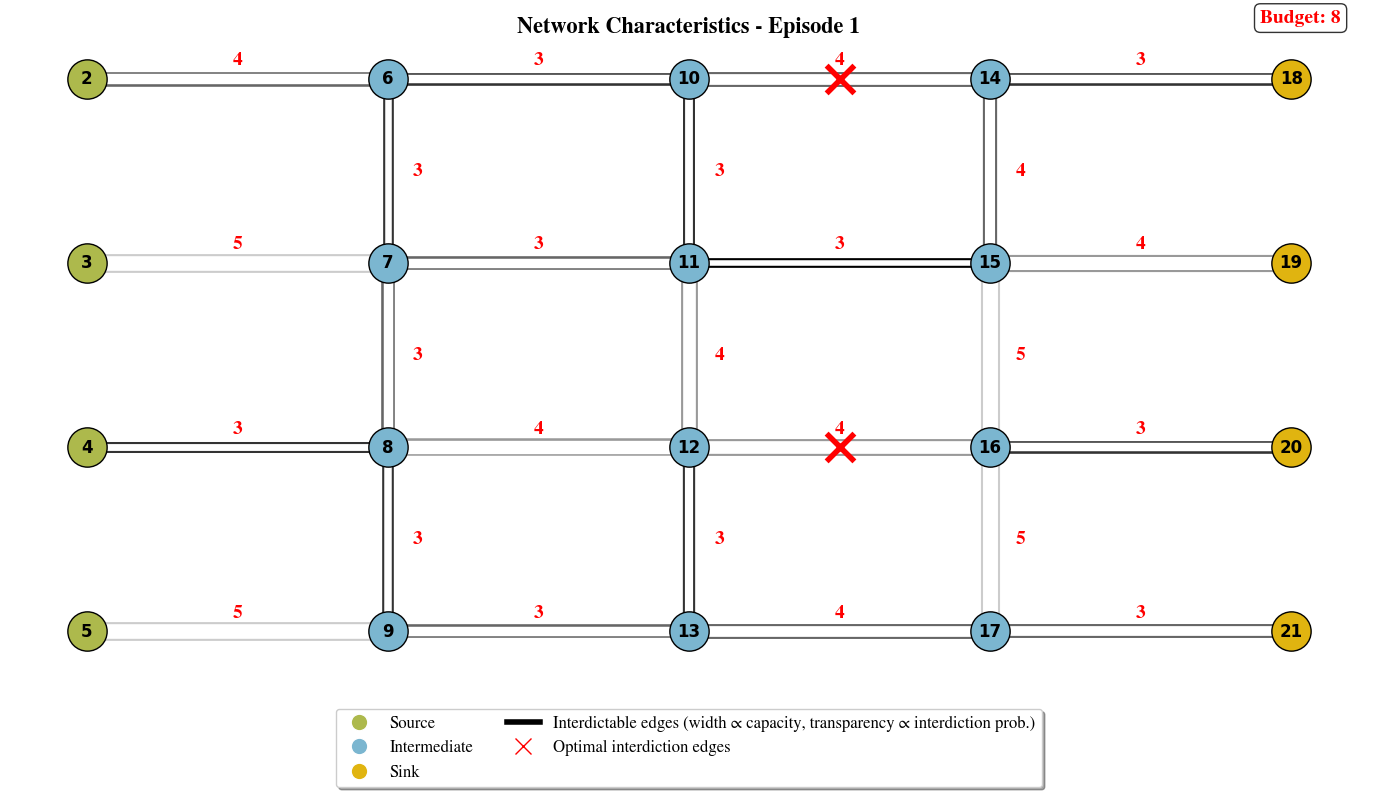

103.82933333333334
709.2309251090046  sec


In [103]:
# Usage with your code:
episode = 1
obs, _ = env.reset(seed=episode)
edge_capacity = obs['edge_capacity']
edge_costs = obs['edge_costs']
edge_interdiction_probability = obs['edge_interdiction_probability']

# Plot the network with optimal interdiction edges marked
G = plot_network_with_edge_annotations(nodes, edges, obs, env, 
                                     all_optimal_interdiction_edges, episode,
                                     title=f"Network Characteristics - Episode {episode}")

print(optimal_obj_vals[episode])
print(optimal_solution_times[episode], " sec")

In [79]:
# Pre-compute constants outside the loop
interdictable_edges_list = list(env.interdictable_edges)

all_agent_actions =[]
agent_solution_times = np.zeros(num_of_scenarios)
#optimal_solution_times=[]

def mask_fn(env):
    """
    Function to generate action mask based on your validation logic
    """
    # Get current state
    remaining_budget = env.state['budget']
    
    # Create action mask - size should match action space
    action_mask = np.ones(env.action_space.n, dtype=np.float32)
    
    # Mask interdictable edges (first 25 actions)
    for action in range(min(env.num_interdictable_edges, env.action_space.n)):
        if not env._validate_action(action, remaining_budget, env.state['edge_interdicted']):
            action_mask[action] = 0.0
    
    # The "do nothing" action (if it exists) is typically always valid
    # It should be at index env.num_interdictable_edges
    # No additional masking needed for "do nothing" action
    return action_mask

agent.policy.eval()


obs, _ = env.reset(seed=episode)
#print(obs)

action_list = []
action_list_append = action_list.append  # Cache method reference
    
start_time = time.perf_counter()
# Run agent with proper normalization
for _ in range(31):
    if "MaskablePPO" in model_name:
        action, _ = agent.predict(obs, deterministic=True, action_masks=mask_fn(env))
    else:
        action, _ = agent.predict(obs, deterministic=True)
    # Use wrapper's step method
    obs, reward, done, _, _ = env.step(action)  
    # Tally actions using inner environment
    if action != env.num_interdictable_edges:
        action_key = interdictable_edges_list[action]
        action_list_append(action_key)  # Faster than action_list.append()
            
    if done:
        break
end_time = time.perf_counter()
agent_solution_time=(end_time-start_time)

if env_attacker_strategy == "zero_sum":
    objVal, _ = env._compute_objective_and_flows()
elif env_attacker_strategy == "canalize":
    objVal, _ = env._calculate_canalize_objective_and_flows()
elif env_attacker_strategy == "isolate":
    objVal, _ = env._calculate_isolate_objective_and_flows()
elif env_attacker_strategy == "divert":
    objVal, _ = env._calculate_divert_objective_and_flows()

print("Solution Time: ", agent_solution_time, " sec")
print("Objective Value: ", objVal)

print("Agent Actions: ", action_list)

Solution Time:  10.208743700000923  sec
Objective Value:  0.909
Agent Actions:  [(12, 16), (4, 8)]
